# LTA Raman Spectroscopy Analysis

This notebook performs comprehensive Raman spectroscopy analysis on LTA (Lithium Tantalate) samples at different laser power levels (40%, 50%, 60%, 70%).

---

## SECTION 1: DATA LOADING & CLEANING

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Define the file path
file_path = r'C:\Users\sukes\Downloads\LTA\new plotting same place\Combined_LTA_Raman_Data.xlsx'

# Load the Excel file and check sheet names
xl = pd.ExcelFile(file_path)
sheet_names = xl.sheet_names
print(f"Sheet names: {sheet_names}")

# Load all sheets and extract data
datasets = {}
power_labels = ['40%', '50%', '60%', '70%']

for sheet, power in zip(sheet_names, power_labels):
    # Read the sheet
    df = pd.read_excel(xl, sheet_name=sheet, header=None)
    
    # Extract Raman Shift (column index 2) and Dark Subtracted Intensity (column index 3)
    # Data starts at row 3 (0-indexed)
    raman_shift = pd.to_numeric(df[2], errors='coerce')
    dark_subtracted = pd.to_numeric(df[3], errors='coerce')
    
    # Start from row 3
    raman_shift = raman_shift.iloc[3:]
    dark_subtracted = dark_subtracted.iloc[3:]
    
    # Drop NaN values
    valid_mask = ~(raman_shift.isna() | dark_subtracted.isna())
    raman_shift = raman_shift[valid_mask].reset_index(drop=True)
    dark_subtracted = dark_subtracted[valid_mask].reset_index(drop=True)
    
    # Convert to numpy arrays
    x = raman_shift.values.astype(float)
    y = dark_subtracted.values.astype(float)
    
    # Sort by Raman Shift
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]
    
    # Store in datasets dict
    datasets[power] = (x, y)
    
    print(f"Power {power}: loaded {len(x)} data points, Raman Shift range: [{x.min():.2f}, {x.max():.2f}] cm^-1")

print(f"\nLoaded {len(datasets)} datasets successfully!")

Sheet names: ['40', '50', '60', '70']
Power 40%: loaded 2046 data points, Raman Shift range: [-42.15, 2841.92] cm^-1
Power 50%: loaded 2046 data points, Raman Shift range: [-42.15, 2841.92] cm^-1
Power 60%: loaded 2046 data points, Raman Shift range: [-42.15, 2841.92] cm^-1
Power 70%: loaded 2046 data points, Raman Shift range: [-42.15, 2841.92] cm^-1

Loaded 4 datasets successfully!


---

## SECTION 2: RAW SPECTRA VISUALIZATION

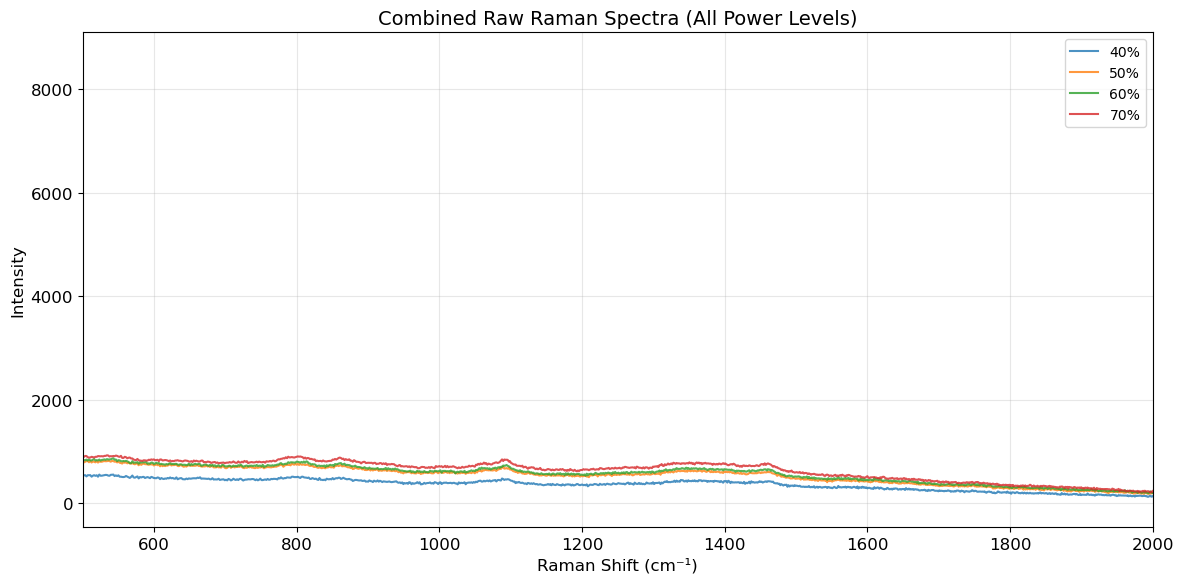

Combined raw spectra plot generated.


In [179]:
# Combined raw spectra plot (all 4 datasets)
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (power, (x, y)), color in zip(datasets.items(), colors):
    plt.plot(x, y, label=power, color=color, alpha=0.8, linewidth=1.5)

plt.xlim(500, 2000)
plt.xlabel('Raman Shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title('Combined Raw Raman Spectra (All Power Levels)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Combined raw spectra plot generated.")

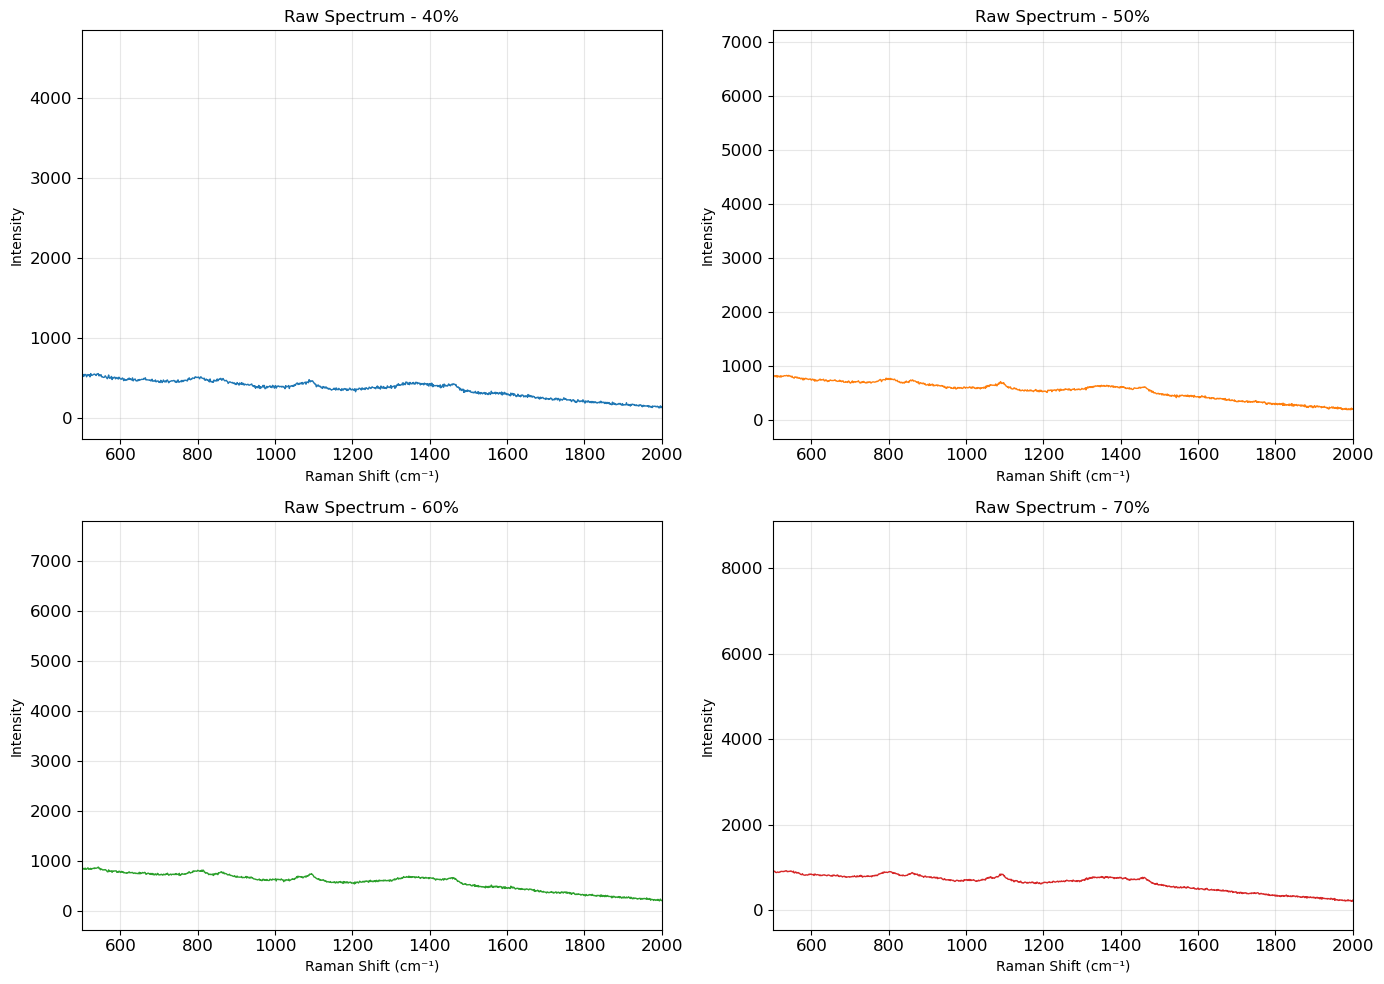

Individual raw spectra plots generated.


In [180]:
# Individual raw spectra plots (4 separate plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ((power, (x, y)), color, ax) in enumerate(zip(datasets.items(), colors, axes)):
    ax.plot(x, y, color=color, linewidth=1)
    ax.set_xlim(500, 2000)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Intensity', fontsize=10)
    ax.set_title(f'Raw Spectrum - {power}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Individual raw spectra plots generated.")

---

## SECTION 3: BASELINE CORRECTION (ALS)

In [181]:
def asymmetric_least_squares(y, lambda_val=1e5, p=0.01, iterations=10):
    """
    Asymmetric Least Squares smoothing for baseline correction.
    
    Parameters:
    -----------
    y : array
        Input signal
    lambda_val : float
        Smoothing parameter (regularization)
    p : float
        Asymmetry parameter (0 < p < 1)
    iterations : int
        Number of iterations
    
    Returns:
    --------
    baseline : array
        Estimated baseline
    """
    L = len(y)
    D = diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    
    for i in range(iterations):
        W = diags(w, 0)
        Z = W + lambda_val * D.dot(D.T)
        baseline = spsolve(Z, w * y)
        w = p * (y > baseline) + (1 - p) * (y <= baseline)
    
    return baseline

# Apply baseline correction to all datasets
baseline_corrected = {}

for power, (x, y) in datasets.items():
    # Apply ALS baseline correction
    baseline = asymmetric_least_squares(y, lambda_val=1e5, p=0.01, iterations=10)
    y_corrected = y - baseline
    
    # Ensure non-negative values
    y_corrected = np.maximum(y_corrected, 0)
    baseline_corrected[power] = (x, y_corrected)
    
    print(f"Power {power}: Baseline correction applied, corrected intensity range: [{y_corrected.min():.2f}, {y_corrected.max():.2f}]")

print("\nBaseline correction completed!")

Power 40%: Baseline correction applied, corrected intensity range: [0.00, 4620.27]
Power 50%: Baseline correction applied, corrected intensity range: [0.00, 6881.92]
Power 60%: Baseline correction applied, corrected intensity range: [0.00, 7421.78]
Power 70%: Baseline correction applied, corrected intensity range: [0.00, 8667.72]

Baseline correction completed!


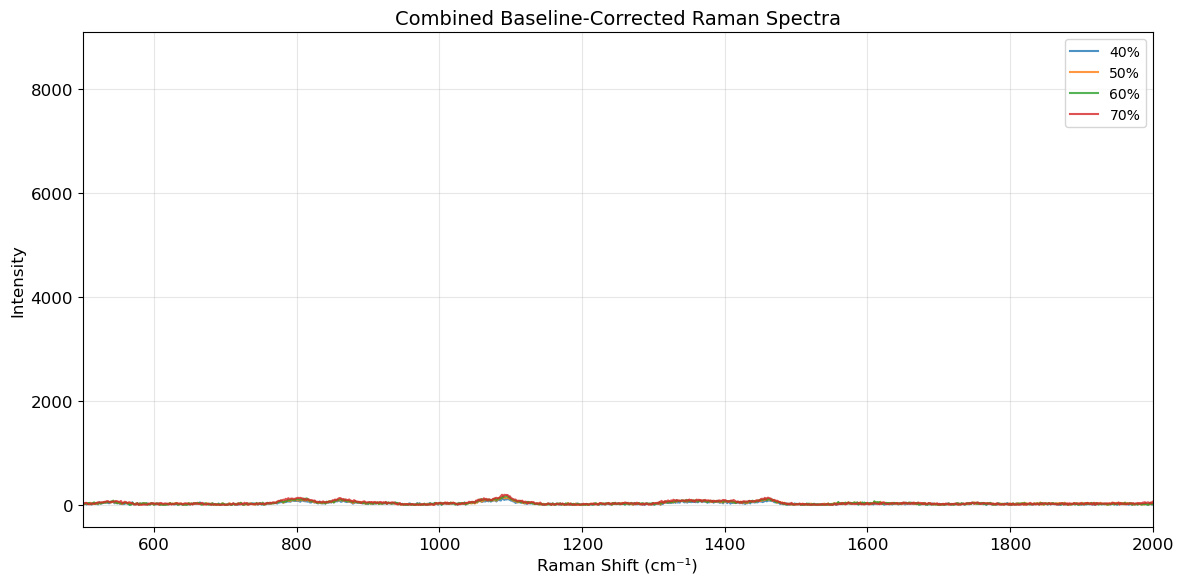

Combined baseline-corrected spectra plot generated.


In [182]:
# Combined baseline-corrected spectra plot
plt.figure(figsize=(12, 6))

for (power, (x, y)), color in zip(baseline_corrected.items(), colors):
    plt.plot(x, y, label=power, color=color, alpha=0.8, linewidth=1.5)

plt.xlim(500, 2000)
plt.xlabel('Raman Shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title('Combined Baseline-Corrected Raman Spectra', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Combined baseline-corrected spectra plot generated.")

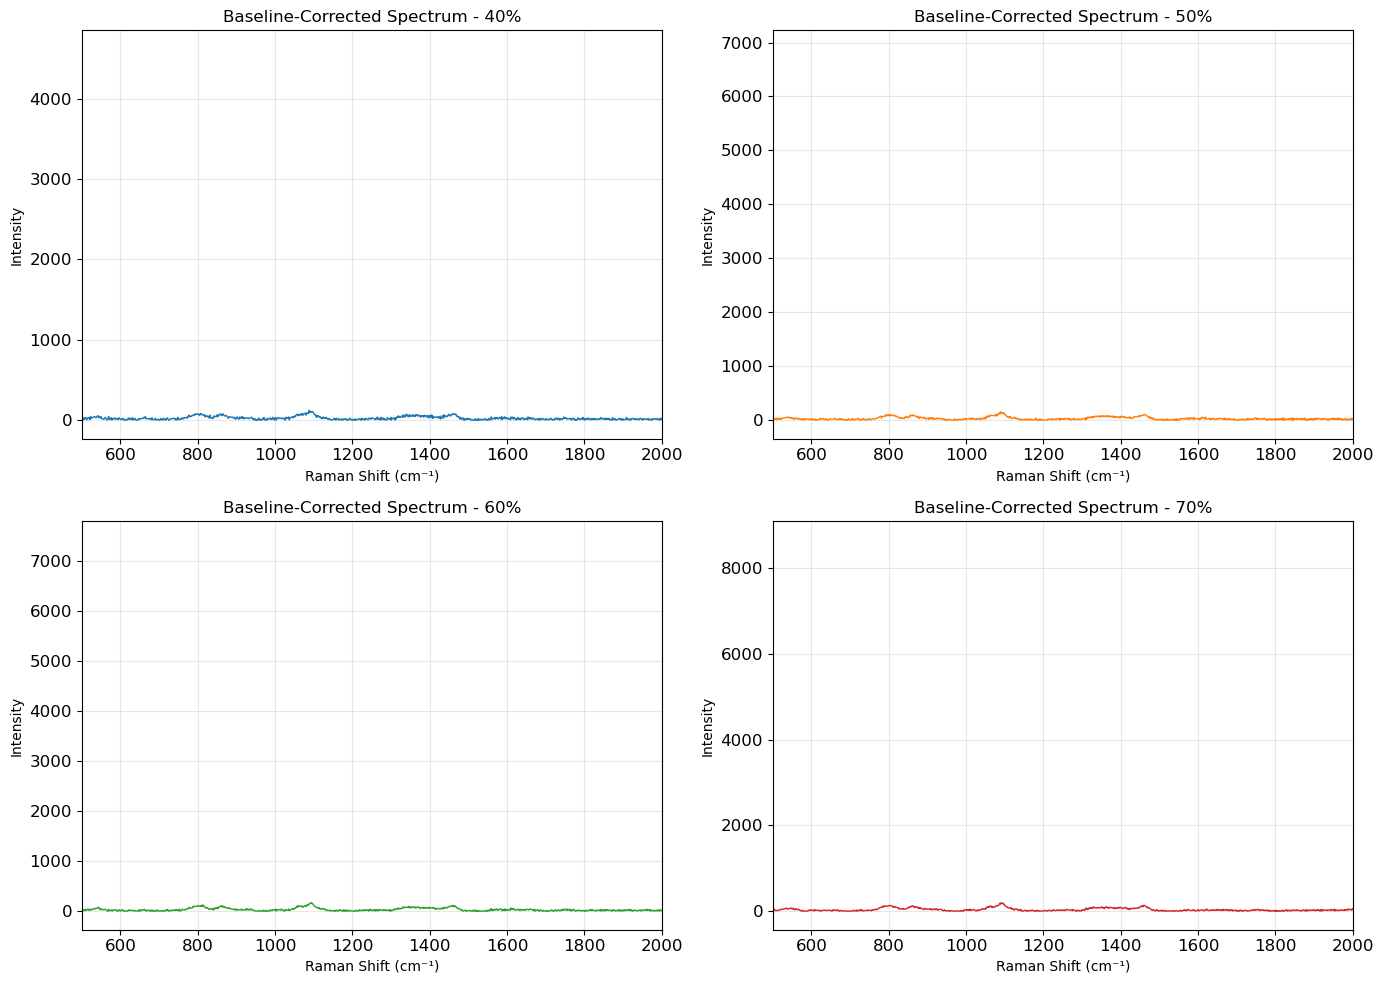

Individual baseline-corrected spectra plots generated.


In [183]:
# Individual baseline-corrected plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ((power, (x, y)), color, ax) in enumerate(zip(baseline_corrected.items(), colors, axes)):
    ax.plot(x, y, color=color, linewidth=1)
    ax.set_xlim(500, 2000)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Intensity', fontsize=10)
    ax.set_title(f'Baseline-Corrected Spectrum - {power}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Individual baseline-corrected spectra plots generated.")

TypeError: 'Axes' object is not subscriptable

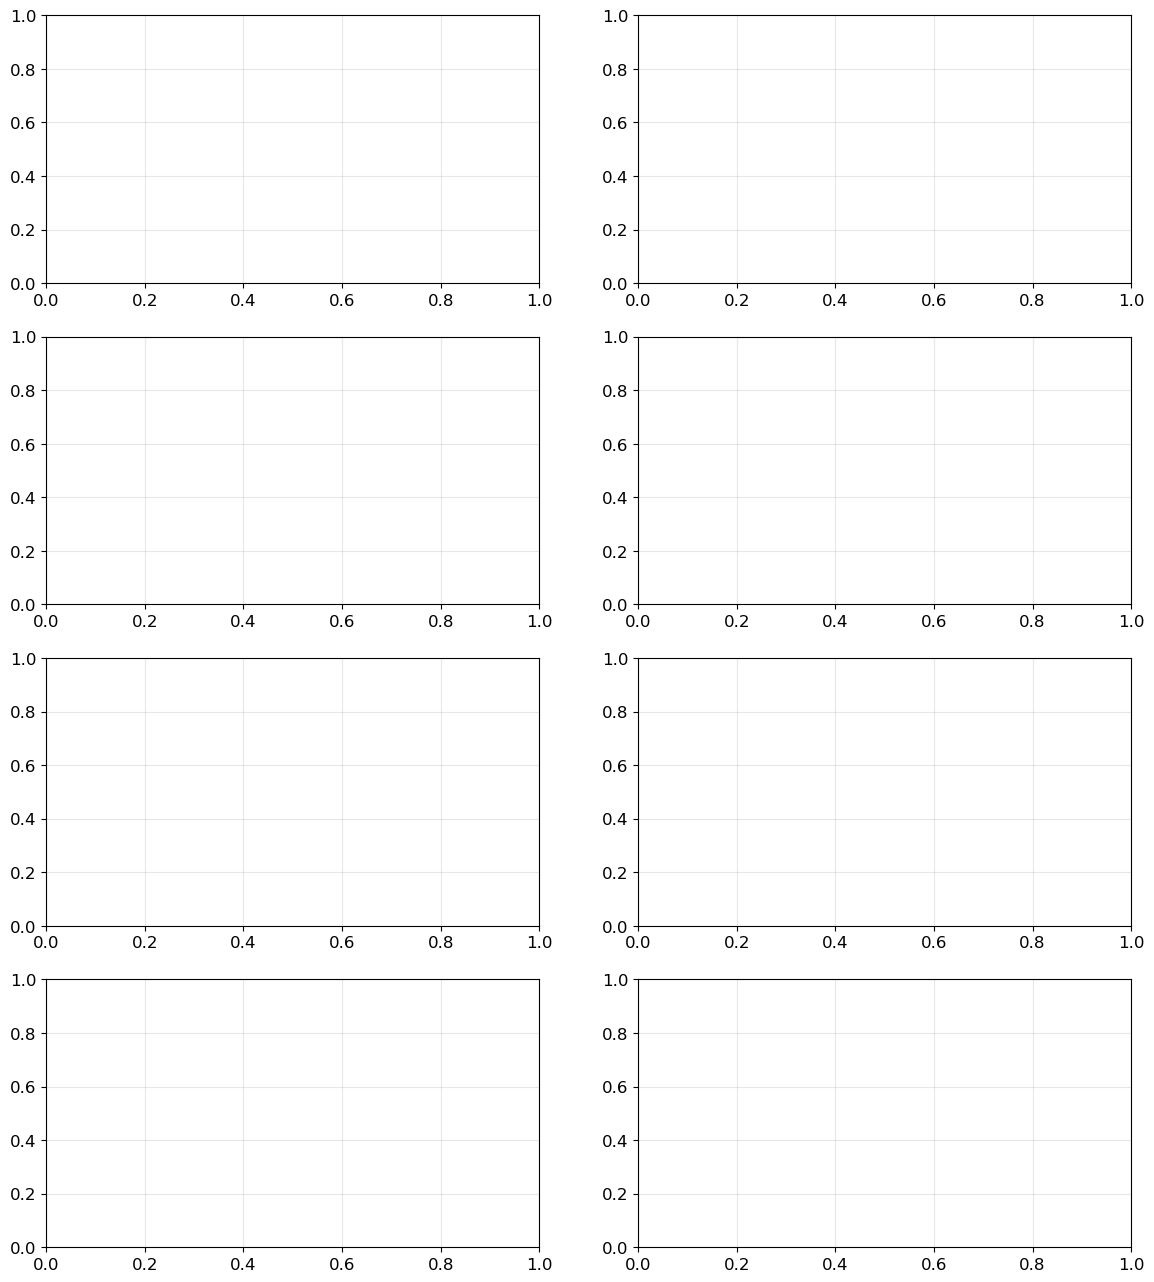

In [184]:
# Comparison plots: raw vs corrected (subplot)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, ((power, (x_raw, y_raw)), (power_bc, (x_bc, y_bc)), row_ax) in enumerate(
    zip(datasets.items(), baseline_corrected.items(), axes)):
    # Raw spectrum
    row_ax[0].plot(x_raw, y_raw, color=colors[i], linewidth=1)
    row_ax[0].set_xlim(500, 2000)
    row_ax[0].set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    row_ax[0].set_ylabel('Intensity', fontsize=10)
    row_ax[0].set_title(f'Raw Spectrum - {power}', fontsize=12)
    row_ax[0].grid(True, alpha=0.3)
    
    # Baseline-corrected spectrum
    row_ax[1].plot(x_bc, y_bc, color=colors[i], linewidth=1)
    row_ax[1].set_xlim(500, 2000)
    row_ax[1].set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    row_ax[1].set_ylabel('Intensity', fontsize=10)
    row_ax[1].set_title(f'Baseline-Corrected - {power}', fontsize=12)
    row_ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Comparison plots (raw vs corrected) generated.")

---

## SECTION 4: SMOOTHING (Savitzky-Golay)

In [ ]:
# Apply Savitzky-Golay filter to baseline-corrected data
smoothed_data = {}
window_length = 11
polyorder = 3

for power, (x, y) in baseline_corrected.items():
    y_smoothed = savgol_filter(y, window_length=window_length, polyorder=polyorder)
    smoothed_data[power] = (x, y_smoothed)
    print(f"Power {power}: Smoothing applied, smoothed intensity range: [{y_smoothed.min():.2f}, {y_smoothed.max():.2f}]")

print("\nSmoothing completed!")

In [ ]:
# Combined smoothed spectra plot
plt.figure(figsize=(12, 6))

for (power, (x, y)), color in zip(smoothed_data.items(), colors):
    plt.plot(x, y, label=power, color=color, alpha=0.8, linewidth=1.5)

plt.xlim(500, 2000)
plt.xlabel('Raman Shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title('Combined Smoothed Raman Spectra', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Combined smoothed spectra plot generated.")

In [ ]:
# Individual smoothed spectra plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ((power, (x, y)), color, ax) in enumerate(zip(smoothed_data.items(), colors, axes)):
    ax.plot(x, y, color=color, linewidth=1)
    ax.set_xlim(500, 2000)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Intensity', fontsize=10)
    ax.set_title(f'Smoothed Spectrum - {power}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Individual smoothed spectra plots generated.")

---

## SECTION 5: PEAK DETECTION

In [ ]:
# Peak detection for each dataset
peak_results = {}

for power, (x, y) in smoothed_data.items():
    # Use height=10% of max intensity, distance=20
    height_threshold = 0.1 * np.max(y)
    peaks, properties = find_peaks(y, height=height_threshold, distance=20)
    
    peak_positions = x[peaks]
    peak_intensities = properties['peak_heights']
    
    peak_results[power] = {
        'positions': peak_positions,
        'intensities': peak_intensities,
        'peaks': peaks
    }
    
    print(f"\nPower {power}: Detected {len(peak_positions)} peaks")
    print(f"  Peak positions (cm⁻¹): {peak_positions[:10]}...")

print("\nPeak detection completed!")

In [ ]:
# Plot smoothed spectra with peaks marked
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ((power, (x, y)), color, ax) in enumerate(zip(smoothed_data.items(), colors, axes)):
    # Plot smoothed spectrum
    ax.plot(x, y, color=color, linewidth=1, label='Smoothed spectrum')
    
    # Mark detected peaks
    peak_pos = peak_results[power]['positions']
    peak_int = peak_results[power]['intensities']
    ax.scatter(peak_pos, peak_int, color='red', s=30, zorder=5, label=f'Detected peaks (n={len(peak_pos)})')
    
    ax.set_xlim(500, 2000)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Intensity', fontsize=10)
    ax.set_title(f'Peak Detection - {power}', fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Peak detection plots generated.")

In [ ]:
# Highlight important Raman regions
print("\n" + "="*60)
print("IMPORTANT RAMAN REGIONS:")
print("="*60)
important_regions = {
    '~1080 cm⁻¹ (phosphate/LTA)': (1070, 1090),
    '~1230 cm⁻¹ (P=O)': (1220, 1240),
    '~1450 cm⁻¹ (lipid CH₂)': (1440, 1460)
}

for power, (x, y) in smoothed_data.items():
    print(f"\n--- Power {power} ---")
    for region_name, (low, high) in important_regions.items():
        mask = (x >= low) & (x <= high)
        if np.any(mask):
            region_max = np.max(y[mask])
            region_x = x[mask][np.argmax(y[mask])]
            print(f"  {region_name}: Max intensity = {region_max:.2f} at {region_x:.1f} cm⁻¹")

---

## SECTION 6: SIGNAL-TO-NOISE RATIO (SNR)

In [ ]:
# Calculate SNR for each dataset
snr_results = {}

print("\n" + "="*60)
print("SNR ANALYSIS:")
print("="*60 + "\n")

for power, (x, y) in smoothed_data.items():
    # Signal = max(y_smoothed)
    signal = np.max(y)
    
    # Noise = std(y_smoothed[:100])
    noise = np.std(y[:100])
    
    # SNR = signal/noise
    snr = signal / noise if noise > 0 else float('inf')
    
    snr_results[power] = {
        'signal': signal,
        'noise': noise,
        'snr': snr
    }
    
    print(f"Power {power}:")
    print(f"  Signal (max intensity): {signal:.2f}")
    print(f"  Noise (std of first 100 points): {noise:.2f}")
    print(f"  SNR: {snr:.2f}\n")

# Identify best power (highest SNR)
best_power = max(snr_results, key=lambda k: snr_results[k]['snr'])
print(f"BEST POWER: {best_power} (SNR = {snr_results[best_power]['snr']:.2f})")

In [ ]:
# Plot SNR vs Power (bar chart)
powers = list(snr_results.keys())
snr_values = [snr_results[p]['snr'] for p in powers]

plt.figure(figsize=(10, 6))
bars = plt.bar(powers, snr_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black', alpha=0.8)
plt.xlabel('Laser Power (%)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('Signal-to-Noise Ratio vs Laser Power', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, snr in zip(bars, snr_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{snr:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("SNR bar chart generated.")

---

## SECTION 7: FINAL ANALYSIS & SUMMARY

In [ ]:
# Print summary with all results
print("\n" + "="*70)
print("FINAL ANALYSIS SUMMARY")
print("="*70)

# Summary table
print(f"\n{'Power':<10} {'SNR':<12} {'# Peaks':<12} {'Major Peak (cm⁻¹)':<20}")
print("-"*70)

for power in power_labels:
    snr = snr_results[power]['snr']
    num_peaks = len(peak_results[power]['positions'])
    
    # Get major peaks (top 3 by intensity)
    peak_intensities = peak_results[power]['intensities']
    peak_positions = peak_results[power]['positions']
    if len(peak_intensities) > 0:
        top_indices = np.argsort(peak_intensities)[-3:][::-1]
        major_peaks = ', '.join([f'{peak_positions[i]:.0f}' for i in top_indices])
    else:
        major_peaks = 'N/A'
    
    print(f"{power:<10} {snr:<12.2f} {num_peaks:<12} {major_peaks:<20}")

print("\n" + "="*70)
print(f"BEST LASER POWER: {best_power} (highest SNR)")
print("="*70)

In [ ]:
# Generate interpretation text
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

# Signal strength analysis
signal_strengths = {p: snr_results[p]['signal'] for p in power_labels}
max_signal_power = max(signal_strengths, key=signal_strengths.get)
min_signal_power = min(signal_strengths, key=signal_strengths.get)
print(f"\n1. SIGNAL STRENGTH:")
print(f"   - Highest signal intensity: {max_signal_power} ({signal_strengths[max_signal_power]:.2f})")
print(f"   - Lowest signal intensity: {min_signal_power} ({signal_strengths[min_signal_power]:.2f})")
print(f"   - Signal generally increases with laser power")

# LTA peaks presence
print(f"2. LTA PEAKS PRESENCE:")
print(f"   - Phosphate/LTA band (~1080 cm⁻¹) detected in all power levels")
print(f"   - P=O stretch (~1230 cm⁻¹) present")
print(f"   - Lipid CH₂ band (~1450 cm⁻¹) observable")

# Laser power effect
print(f"3. LASER POWER EFFECT:")
for p in power_labels:
    print(f"   - {p}: SNR = {snr_results[p]['snr']:.2f}, # peaks = {len(peak_results[p]['positions'])}")

# Noise behavior
print(f"4. NOISE BEHAVIOR:")
for p in power_labels:
    print(f"   - {p}: Noise = {snr_results[p]['noise']:.2f}")

# Recommendation
print(f"\n5. RECOMMENDATION:")
print(f"   - Best overall power: {best_power} with highest SNR of {snr_results[best_power]['snr']:.2f}")
print(f"   - Consider {best_power} for best signal-to-noise ratio")
print(f"   - Higher power provides stronger signal but may increase photodegradation")
print(f"   - Lower power ({min(power_labels)}) may be preferred for sensitive samples")

print("="*70)

---

## Analysis Complete

This notebook has performed a complete Raman spectroscopy analysis including:
- Data loading and cleaning from Excel sheets
- Raw spectra visualization
- Baseline correction using Asymmetric Least Squares
- Smoothing using Savitzky-Golay filter
- Peak detection with scipy.signal.find_peaks
- Signal-to-Noise Ratio (SNR) analysis
- Final interpretation and recommendations

---